# DDPG Navigation — Ozzy Segway

Drop-in replacement alongside `PPO_NAV_OzzyVer.ipynb` and `SAC_NAV_OzzyVer.ipynb`.

| vs SAC | DDPG difference | Why |
|---|---|---|
| Stochastic actor (Gaussian + tanh) | **Deterministic** actor (tanh only) | Simpler, but no built-in exploration |
| Twin Q-networks (Q1 + Q2) | **Single** Q-network | Original DDPG predates twin trick |
| Target critic only | Target **actor + critic** | Both needed for stable Bellman targets |
| Auto entropy tuning (α) | **Gaussian noise** on actions | External exploration, manually scaled |
| `actor.sample()` for update | Direct `actor(obs)` for update | No reparameterization through noise |

Everything else is identical: same env, obs, reward, replay buffer, eval, plot, record functions.

In [11]:
import mujoco
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import os, imageio, base64, time, json
from collections import deque
from scipy.spatial.transform import Rotation
from IPython.display import display, HTML
from PIL import Image as PILImage, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

XML_PATH     = "/Users/kchong99/Documents/Master/ME 569/owsbr/Ozzy/segway_2.xml"
SAVE_DIR     = "SavedSeeds"
TRAIN_SEEDS  = [42]
VERIFY_SEEDS = [788, 999, 555, 321, 444]
os.makedirs(SAVE_DIR, exist_ok=True)

## Ground contact lookup (UNCHANGED)

In [12]:
def get_ground_contact_z(xml_path, tilt=0.0):
    model = mujoco.MjModel.from_xml_path(xml_path)
    data  = mujoco.MjData(model)
    mujoco.mj_resetData(model, data)
    rot  = Rotation.from_euler('y', tilt)
    quat = rot.as_quat()
    data.qpos[3:7] = [quat[3], quat[0], quat[1], quat[2]]
    data.qpos[2]   = 2.0
    data.qvel[:]   = 0.0
    mujoco.mj_forward(model, data)
    for _ in range(2000):
        data.ctrl[:] = 0.0
        mujoco.mj_step(model, data)
        if abs(data.qvel[2]) < 0.001 and data.qpos[2] < 0.5:
            break
    return data.qpos[2]

print("Building ground contact lookup table...")
GROUND_Z_TABLE = {}
for tilt in np.arange(0.0, 1.1, 0.05):
    GROUND_Z_TABLE[round(tilt, 2)]  = get_ground_contact_z(XML_PATH, tilt)
    GROUND_Z_TABLE[round(-tilt, 2)] = GROUND_Z_TABLE[round(tilt, 2)]
print("Done.")

def get_z_for_tilt(tilt):
    key = round(round(abs(tilt) / 0.05) * 0.05, 2)
    return GROUND_Z_TABLE.get(min(key, 1.0), GROUND_Z_TABLE[0.0])

Building ground contact lookup table...
Done.


## Observation helpers (UNCHANGED)

In [13]:
def get_obs(data):
    quat  = data.qpos[3:7]
    rot   = Rotation.from_quat([quat[1], quat[2], quat[3], quat[0]])
    theta = rot.as_euler('xyz')[1]
    return np.array([data.qpos[0], data.qvel[0], theta, data.qvel[4]], dtype=np.float32)

def normalize_obs(obs):
    x, xd, th, thd = obs
    return np.array([
        np.clip(x   / 2.4,  -1, 1),
        np.clip(xd  / 5.0,  -1, 1),
        np.clip(th  / 1.57, -1, 1),
        np.clip(thd / 5.0,  -1, 1),
    ], dtype=np.float32)

## Reward function (UNCHANGED)

In [14]:
def nav_reward(obs, prev_x, goal_x, at_goal, done, step):
    x, xd, theta, thd = obs
    if done:    return -20.0
    if at_goal: return  50.0
    r  = (abs(prev_x - goal_x) - abs(x - goal_x)) * 15.0
    r -= abs(x - goal_x) * 0.05
    r += 0.02
    if abs(theta) > 0.20:
        r -= (abs(theta) - 0.2) * 5.0
    return float(r)

## Shared RunLogger (UNCHANGED)

In [15]:
class RunLogger:
    def __init__(self, algo, seed, log_every_steps=2000,
                 arrival_window=200, reward_window=100):
        self.algo  = algo
        self.seed  = seed
        self.t0    = time.time()
        self.log_every = log_every_steps
        self._next_log = log_every_steps
        self.rewards         = []
        self.recent_arrivals = deque(maxlen=arrival_window)
        self.reward_window   = reward_window
        self.rows = []
        self.steps_to_converge = None

    def episode_end(self, total_steps, ep_count, ep_return, arrived, loss):
        self.rewards.append(ep_return)
        self.recent_arrivals.append(1 if arrived else 0)
        avg_reward  = float(np.mean(self.rewards[-self.reward_window:]))
        arrival_pct = float(np.mean(self.recent_arrivals) * 100) if self.recent_arrivals else 0.0
        if (self.steps_to_converge is None
                and len(self.recent_arrivals) == self.recent_arrivals.maxlen
                and arrival_pct >= 100.0):
            self.steps_to_converge = total_steps
        if total_steps >= self._next_log:
            self.rows.append({
                "steps": int(total_steps), "episodes": int(ep_count),
                "wall_time": round(time.time() - self.t0, 2),
                "avg_reward": round(avg_reward, 3),
                "arrival_pct": round(arrival_pct, 2),
                "loss": round(float(loss), 4),
            })
            self._next_log += self.log_every
        return avg_reward, arrival_pct

    def save(self, save_dir, tag, eval_results=None):
        os.makedirs(save_dir, exist_ok=True)
        payload = {
            "algo": self.algo, "seed": self.seed,
            "total_wall_time": round(time.time() - self.t0, 2),
            "total_steps": self.rows[-1]["steps"] if self.rows else 0,
            "total_episodes": self.rows[-1]["episodes"] if self.rows else 0,
            "steps_to_converge": self.steps_to_converge,
            "timeseries": self.rows, "eval_results": eval_results,
        }
        path = f"{save_dir}/cmp_{self.algo}_seed{tag}.json"
        json.dump(payload, open(path, "w"), indent=2)
        print(f"  [logger] saved {path}")
        return path

## DDPG Networks ← **NEW**

DDPG uses a **deterministic** actor and a **single** Q-network — simpler than SAC in every way.

| SAC | DDPG |
|---|---|
| Actor outputs mean + state-dependent std | Actor outputs mean only |
| Exploration from policy stochasticity | Exploration from additive Gaussian noise |
| Twin Q-networks (Q1, Q2) | Single Q-network |
| Target critic only | Target actor + target critic |
| Entropy coefficient α (learned) | Noise scale σ (fixed or decayed) |

In [16]:
class DDPGActor(nn.Module):
    """
    Deterministic actor.
    Input : 5-dim (4 normalised obs + goal distance)
    Output: torque in (-torque_max, torque_max) via tanh
    get_action() has the same signature as PPO/SAC — drop-in compatible.
    """
    def __init__(self, torque_max=5.0):
        super().__init__()
        self.torque_max = torque_max
        self.net = nn.Sequential(
            nn.Linear(5, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1),  nn.Tanh(),   # bounded output
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, 0.5)
                nn.init.zeros_(m.bias)
        # smaller init on final layer for stable starting actions
        nn.init.uniform_(list(self.modules())[-2].weight, -3e-3, 3e-3)

    def forward(self, x):
        return self.net(x) * self.torque_max   # scale tanh to ±torque_max

    def get_action(self, obs, goal_x, deterministic=False, noise_std=0.1):
        """
        Same signature as PPO/SAC get_action.
        Returns (torque, None, None). Exploration noise added when not deterministic.
        """
        dist_norm = float(np.clip((goal_x - obs[0]) / 5., -1, 1))
        inp = torch.FloatTensor([*normalize_obs(obs), dist_norm]).unsqueeze(0)
        with torch.no_grad():
            torque = self(inp).item()
            if not deterministic:
                torque += np.random.normal(0, noise_std * self.torque_max)
                torque = float(np.clip(torque, -self.torque_max, self.torque_max))
        return torque, None, None


class DDPGCritic(nn.Module):
    """
    Single Q-network (no twin).
    Input : 5-dim obs + 1-dim action = 6 total
    Output: scalar Q-value
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, 0.5)
                nn.init.zeros_(m.bias)

    def forward(self, obs_t, act_t):
        x = torch.cat([obs_t, act_t], dim=-1)
        return self.net(x)

## Replay Buffer

In [17]:
class ReplayBuffer:
    def __init__(self, capacity=1_000_000, obs_dim=5):
        self.cap  = capacity
        self.ptr  = self.size = 0
        self.obs  = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.act  = np.zeros((capacity, 1),       dtype=np.float32)
        self.rew  = np.zeros((capacity, 1),       dtype=np.float32)
        self.obs2 = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.done = np.zeros((capacity, 1),       dtype=np.float32)

    def push(self, o, a, r, o2, d):
        self.obs[self.ptr]=o; self.act[self.ptr]=[a]
        self.rew[self.ptr]=r; self.obs2[self.ptr]=o2; self.done[self.ptr]=d
        self.ptr  = (self.ptr + 1) % self.cap
        self.size = min(self.size + 1, self.cap)

    def sample(self, n=256):
        i = np.random.randint(0, self.size, n)
        return (torch.FloatTensor(self.obs[i]),  torch.FloatTensor(self.act[i]),
                torch.FloatTensor(self.rew[i]),  torch.FloatTensor(self.obs2[i]),
                torch.FloatTensor(self.done[i]))

    def __len__(self): return self.size

## DDPG `train_nav` ← **NEW**

Simpler than SAC's update — no entropy, no alpha, no twin Q. The update is:

```
Critic:   y = r + γ(1-d) · Q_tgt(s', μ_tgt(s'))
          L_Q = MSE(Q(s,a), y)

Actor:    L_μ = -mean( Q(s, μ(s)) )       ← deterministic policy gradient

Targets:  θ_tgt ← (1-τ) θ_tgt + τ θ       (both actor and critic)
```

In [18]:
def train_nav(x_start=0.0, x_goal=2.0,
              seed=42, tag="nav_ddpg_v1",
              max_steps=3000000):
    """
    DDPG drop-in for PPO/SAC train_nav.
    Returns (actor, rewards, losses, logger) — identical shape.
    actor.get_action() has the same API so eval/record/plot work unchanged.
    """
    torch.manual_seed(seed); np.random.seed(seed)

    GAMMA        = 0.99
    TAU          = 0.005
    LR_ACTOR     = 1e-4       # lower than SAC — DDPG actors are more sensitive
    LR_CRITIC    = 3e-4
    BATCH        = 256
    WARMUP       = 5_000
    MAX_EP_STEPS = 3000
    NOISE_START  = 0.3        # exploration noise std (fraction of torque_max)
    NOISE_END    = 0.1
    NOISE_DECAY  = 1_000_000    # steps over which noise decays

    actor      = DDPGActor(torque_max=5.0)
    critic     = DDPGCritic()
    # DDPG has target networks for BOTH actor and critic (unlike SAC: critic only)
    actor_tgt  = DDPGActor(torque_max=5.0)
    critic_tgt = DDPGCritic()
    actor_tgt.load_state_dict(actor.state_dict())
    critic_tgt.load_state_dict(critic.state_dict())
    for p in actor_tgt.parameters():  p.requires_grad = False
    for p in critic_tgt.parameters(): p.requires_grad = False

    actor_opt  = optim.Adam(actor.parameters(),  lr=LR_ACTOR)
    critic_opt = optim.Adam(critic.parameters(), lr=LR_CRITIC)

    replay = ReplayBuffer(1_000_000, obs_dim=5)

    model = mujoco.MjModel.from_xml_path(XML_PATH)
    data  = mujoco.MjData(model)

    def reset_env():
        mujoco.mj_resetData(model, data)
        data.qpos[0]=x_start; data.qpos[1]=0.0
        data.qpos[2]=get_z_for_tilt(0.0); data.qpos[3:7]=[1,0,0,0]
        data.qvel[:]=0.0; data.qvel[4]=np.random.uniform(-0.01,0.01)
        mujoco.mj_forward(model, data); return get_obs(data)

    def env_step(torque):
        u=float(np.clip(torque,-5.,5.)); data.ctrl[0]=-u; data.ctrl[1]=0.0
        mujoco.mj_step(model,data); obs=get_obs(data); x,_,th,_=obs
        return obs, (abs(x)>2.8 or abs(th)>0.5), (abs(x-x_goal)<0.10 and abs(th)<0.25)

    def make_inp(obs):
        return np.array([*normalize_obs(obs),
                         float(np.clip((x_goal-obs[0])/5.,-1,1))], dtype=np.float32)

    def get_noise_std(step):
        """Linear decay of exploration noise."""
        frac = min(1.0, step / NOISE_DECAY)
        return NOISE_START + (NOISE_END - NOISE_START) * frac

    def ddpg_update():
        if len(replay) < BATCH: return 0.0
        ob, ac, re, ob2, dn = replay.sample(BATCH)

        # --- critic update ---
        with torch.no_grad():
            # target action from target actor (deterministic — no noise)
            next_act = actor_tgt(ob2)
            qt = critic_tgt(ob2, next_act)
            y  = re + GAMMA * (1 - dn) * qt
        q = critic(ob, ac)
        cl = nn.MSELoss()(q, y)
        critic_opt.zero_grad(); cl.backward()
        nn.utils.clip_grad_norm_(critic.parameters(), 1.0)
        critic_opt.step()

        # --- actor update (deterministic policy gradient) ---
        # maximize Q(s, μ(s)) → minimize -Q
        al = -critic(ob, actor(ob)).mean()
        actor_opt.zero_grad(); al.backward()
        nn.utils.clip_grad_norm_(actor.parameters(), 1.0)
        actor_opt.step()

        # --- soft target update (both actor and critic) ---
        with torch.no_grad():
            for p, pt in zip(critic.parameters(), critic_tgt.parameters()):
                pt.data.mul_(1 - TAU); pt.data.add_(TAU * p.data)
            for p, pt in zip(actor.parameters(), actor_tgt.parameters()):
                pt.data.mul_(1 - TAU); pt.data.add_(TAU * p.data)

        return cl.item()

    logger = RunLogger("DDPG", seed, log_every_steps=2000)
    rewards=[]; losses=[]; best_avg=-9999; best_weights=None
    total_steps = ep_count = 0

    print(f"\nDDPG | A={x_start}m -> B={x_goal}m | budget={max_steps:,} steps")
    print(f"{'Steps':>9} | {'Ep':>5} | {'Avg100':>8} | {'Rec%':>6} | {'Noise':>6} | {'CritL':>8}")
    print("-"*62)

    while total_steps < max_steps:
        obs=reset_env(); ep_ret=0.0; prev_x=obs[0]; ep_step=0; ep_cls=[]
        arrived_flag = False

        for _ in range(MAX_EP_STEPS):
            noise_std = get_noise_std(total_steps)
            if total_steps < WARMUP:
                torque = np.random.uniform(-5., 5.)
            else:
                torque, _, _ = actor.get_action(obs, x_goal,
                                                deterministic=False,
                                                noise_std=noise_std)

            obs2, done, at_goal = env_step(torque)
            ep_step += 1; total_steps += 1
            r = nav_reward(obs2, prev_x, x_goal, at_goal, done, ep_step)
            ep_ret += r; prev_x = obs2[0]
            replay.push(make_inp(obs), torque, r, make_inp(obs2), float(done or at_goal))

            if total_steps >= WARMUP:
                ep_cls.append(ddpg_update())
            obs = obs2
            if done or at_goal or ep_step >= MAX_EP_STEPS:
                arrived_flag = at_goal
                break
            if total_steps >= max_steps: break

        ep_count += 1
        ep_loss = float(np.mean(ep_cls)) if ep_cls else 0.0
        rewards.append(ep_ret); losses.append(ep_loss)
        avg, rp = logger.episode_end(total_steps, ep_count, ep_ret, arrived_flag, ep_loss)

        if ep_count % 50 == 0:
            ns = get_noise_std(total_steps)
            icon = "✅" if avg > 0 else "🔄" if avg > -20 else "⏳"
            print(f"{total_steps:>9,} | {ep_count:>5} | {avg:>8.2f} | "
                  f"{rp:>5.1f}% | {ns:>5.3f} | {ep_loss:>8.3f} {icon}", flush=True)
            if avg > best_avg:
                best_avg = avg
                best_weights = {k: v.clone() for k, v in actor.state_dict().items()}
                torch.save(actor.state_dict(), f"{SAVE_DIR}/nav_ddpg_{tag}.pth")

    if best_weights: actor.load_state_dict(best_weights)
    return actor, rewards, losses, logger

## Train, Verify, Plot, Record

In [19]:
def train_one_verify_many(algo_label="DDPG",
                          train_seed=42,
                          verify_seeds=(788,999,555,321,444,123,777,256,512,111),
                          x_start=0.0, x_goal=2.0,
                          step_budget=500_000):
    verify_seeds = list(verify_seeds)
    print(f"\n{'='*60}\n  {algo_label}  TRAIN seed = {train_seed}\n{'='*60}")
    net, rewards, losses, logger = train_nav(
        x_start=x_start, x_goal=x_goal,
        seed=train_seed, tag=f"cmp_seed{train_seed}",
        max_steps=step_budget)

    def eval_policy(net, seed, n=20):
        torch.manual_seed(seed); np.random.seed(seed)
        model=mujoco.MjModel.from_xml_path(XML_PATH); data=mujoco.MjData(model)
        strict=loose=fell=0; max_xs=[]; times=[]
        for _ in range(n):
            mujoco.mj_resetData(model,data)
            data.qpos[0]=x_start; data.qpos[2]=get_z_for_tilt(0.0)
            data.qpos[3:7]=[1,0,0,0]; data.qvel[:]=0.0
            data.qvel[4]=np.random.uniform(-0.02,0.02)
            mujoco.mj_forward(model,data); obs=get_obs(data); mx=0.0; end="timeout"
            for step in range(3000):
                with torch.no_grad():
                    t,_,_=net.get_action(obs,x_goal,deterministic=True)
                data.ctrl[0]=-float(np.clip(t,-5,5)); data.ctrl[1]=0.0
                mujoco.mj_step(model,data); obs=get_obs(data); x,_,th,_=obs
                mx=max(mx,x)
                if abs(x)>2.8 or abs(th)>0.5: end="fell"; break
                if abs(x-x_goal)<0.10 and abs(th)<0.35:
                    end="strict"; times.append(step*model.opt.timestep); break
                elif abs(x-x_goal)<0.25 and abs(th)<0.35:
                    end="loose"; times.append(step*model.opt.timestep)
            strict+=end=="strict"; loose+=end=="loose"; fell+=end=="fell"
            max_xs.append(mx)
        return {"strict_pct":strict/n*100,"loose_pct":(strict+loose)/n*100,
                "fell_pct":fell/n*100,"avg_max_x":float(np.mean(max_xs)),
                "avg_time":float(np.mean(times)) if times else 999.0}

    print(f"\n  Verifying on {len(verify_seeds)} unseen seeds:")
    print(f"  {'Seed':>6} | {'Strict%':>8} | {'Loose%':>7} | {'Fell%':>6} | {'Time':>6}")
    print("  " + "-"*48)
    per_seed={}
    for vs in verify_seeds:
        r=eval_policy(net, vs); per_seed[vs]=r
        icon="✅" if r["strict_pct"]>=80 else "🔄" if r["strict_pct"]>=50 else "❌"
        print(f"  {vs:>6} | {r['strict_pct']:>7.0f}% | {r['loose_pct']:>6.0f}% | "
              f"{r['fell_pct']:>5.0f}% | {r['avg_time']:>5.1f}s {icon}")
    summary={
        "train_seed": train_seed, "verify_seeds": verify_seeds,
        "strict_pct": float(np.mean([per_seed[v]["strict_pct"] for v in verify_seeds])),
        "strict_std": float(np.std([per_seed[v]["strict_pct"] for v in verify_seeds])),
        "fell_pct":   float(np.mean([per_seed[v]["fell_pct"]   for v in verify_seeds])),
        "avg_time":   float(np.mean([per_seed[v]["avg_time"]
                                     for v in verify_seeds
                                     if per_seed[v]["avg_time"]<999] or [999])),
        "per_seed": per_seed,
    }
    print(f"\n  DDPG verify avg: {summary['strict_pct']:.1f}% ± {summary['strict_std']:.1f}%")
    logger.save(SAVE_DIR, f"cmp_seed{train_seed}", eval_results=summary)
    return net, logger, summary

## Record all seeds

In [25]:
def record_all_seeds(nav_net,
                     train_seeds=[42],
                     verify_seeds=[788,999,555,321,444],
                     x_start=0.0, x_goal=2.0,
                     max_steps=3000):
    model    = mujoco.MjModel.from_xml_path(XML_PATH)
    data     = mujoco.MjData(model)
    dt       = model.opt.timestep
    renderer = mujoco.Renderer(model, height=480, width=640)
    cam=mujoco.MjvCamera(); cam.type=mujoco.mjtCamera.mjCAMERA_FREE
    cam.lookat=np.array([1.0,0.0,0.3]); cam.distance=4.5
    cam.azimuth=90; cam.elevation=-15
    PX_A=160; PX_B=480
    def world_to_px(wx): return int(PX_A+(wx/x_goal)*(PX_B-PX_A))
    all_seeds=[(s,"TRAIN") for s in train_seeds]+[(s,"VERIFY") for s in verify_seeds]
    print("Recording seeds...")
    for seed,role in all_seeds:
        torch.manual_seed(seed); np.random.seed(seed)
        mujoco.mj_resetData(model,data)
        data.qpos[0]=x_start; data.qpos[1]=0.0
        data.qpos[2]=get_z_for_tilt(0.0); data.qpos[3:7]=[1,0,0,0]
        data.qvel[:]=0.0; mujoco.mj_forward(model,data)
        obs=get_obs(data); frames=[]; strict=arrived=fell=False
        for step in range(max_steps):
            with torch.no_grad():
                torque,_,_ = nav_net.get_action(obs,x_goal,deterministic=True)
            data.ctrl[0]=-float(np.clip(torque,-5,5)); data.ctrl[1]=0.0
            mujoco.mj_step(model,data); obs=get_obs(data); x,_,theta,_=obs
            fell=abs(x)>2.8 or abs(theta)>0.5
            arrived=abs(x-x_goal)<0.25 and abs(theta)<0.35
            strict=abs(x-x_goal)<0.10 and abs(theta)<0.35
            renderer.update_scene(data,camera=cam)
            img=PILImage.fromarray(renderer.render()); draw=ImageDraw.Draw(img); W,H=img.size
            prog=float(np.clip(x/x_goal,0,1)); bw=W-40
            pcol=(0,200,0) if strict else (255,140,0) if arrived else (30,100,220)
            draw.rectangle([20,8,W-20,28],fill=(40,40,40))
            draw.rectangle([20,8,20+int(bw*prog),28],fill=pcol)
            draw.text((22,10),"A",fill=(255,255,255)); draw.text((W-28,10),"B",fill=(255,255,255))
            draw.text((W//2-40,10),f"{prog*100:.0f}%  x={x:.3f}m",fill=(255,255,255))
            badge_col=(0,60,140) if role=="TRAIN" else (100,0,140)
            draw.rectangle([8,34,170,58],fill=badge_col)
            draw.text((12,38),f"[{role}] seed={seed}",fill=(255,255,255))
            if strict:   sc=(0,120,0);   st=f"✓ STRICT  x={x:.3f}m  t={step*dt:.1f}s"
            elif arrived:sc=(120,100,0); st=f"~ LOOSE   x={x:.3f}m  t={step*dt:.1f}s"
            elif fell:   sc=(140,0,0);   st=f"✗ FELL    x={x:.3f}m  θ={np.degrees(theta):.1f}°"
            else:        sc=(20,20,70);  st=f"x={x:+.3f}m  θ={np.degrees(theta):+.1f}°  u={torque:+.1f}Nm  t={step*dt:.1f}s"
            draw.rectangle([175,34,W-8,58],fill=sc); draw.text((178,38),st,fill=(255,255,255))
            my=H-55
            a_px=world_to_px(x_start); b_px=world_to_px(x_goal)
            s_px=world_to_px(float(np.clip(x,-0.3,2.5)))
            draw.line([(a_px-5,my+15),(b_px+5,my+15)],fill=(180,180,180),width=3)
            draw.ellipse([a_px-14,my+4,a_px+14,my+26],fill=(50,100,220),outline=(255,255,255),width=2)
            draw.text((a_px-5,my+8),"A",fill=(255,255,255))
            draw.ellipse([b_px-14,my+4,b_px+14,my+26],fill=(0,180,70),outline=(255,255,255),width=2)
            draw.text((b_px-5,my+8),"B",fill=(255,255,255))
            scol=(0,220,100) if strict else (255,210,0)
            draw.ellipse([s_px-9,my+7,s_px+9,my+23],fill=scol,outline=(255,255,255),width=2)
            frames.append(np.array(img))
            if strict or fell: frames+=[frames[-1]]*60; break
        result="STRICT" if strict else "FELL" if fell else f"LOOSE@{x:.2f}m"
        print(f"  [{role}] seed={seed}: {result}")
        fname=f"nav_ppo_{role.lower()}_seed{seed}.mp4"
        imageio.mimsave(fname,frames,fps=30)
        sz=os.path.getsize(fname)//1024; print(f"    saved {fname} ({sz} KB)")
        b64=base64.b64encode(open(fname,"rb").read()).decode()
        display(HTML(f'<b>[{role}] Seed {seed} — {result}</b><br>'
                     f'<video width="640" height="480" controls autoplay loop>'
                     f'<source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>'))
    print("\nDone.")

In [21]:
# === RUN ===
net, logger, summary = train_one_verify_many("DDPG", train_seed=42, step_budget=2_000_000)


  DDPG  TRAIN seed = 42

DDPG | A=0.0m -> B=2.0m | budget=2,000,000 steps
    Steps |    Ep |   Avg100 |   Rec% |  Noise |    CritL
--------------------------------------------------------------
   10,459 |    50 |   -85.53 |   0.0% | 0.298 |    0.206 ⏳
   89,451 |   100 |  -115.00 |  22.0% | 0.282 |    1.732 ⏳
  175,005 |   150 |  -181.87 |  22.7% | 0.265 |    0.452 ⏳
  262,712 |   200 |  -137.01 |  34.0% | 0.247 |    0.252 ⏳
  362,158 |   250 |  -117.53 |  41.5% | 0.228 |    0.206 ⏳
  471,063 |   300 |  -133.26 |  47.0% | 0.206 |    0.218 ⏳
  554,981 |   350 |   -62.43 |  59.5% | 0.189 |    0.152 ⏳
  641,353 |   400 |   -60.68 |  59.5% | 0.172 |    0.315 ⏳
  722,306 |   450 |   -97.37 |  68.5% | 0.156 |    0.192 ⏳
  776,609 |   500 |   -55.78 |  75.5% | 0.145 |    0.164 ⏳
  845,609 |   550 |   -24.67 |  76.0% | 0.131 |    0.211 ⏳
  914,831 |   600 |   -38.47 |  79.0% | 0.117 |    0.174 ⏳
  976,747 |   650 |   -24.91 |  83.0% | 0.105 |    0.301 ⏳
1,007,975 |   700 |   -30.61 |  68.0%

In [26]:
record_all_seeds(
    net,
    train_seeds  = [42],
    verify_seeds = [788, 999, 555, 321, 444],
    x_goal       = 2.0
)

Recording seeds...
  [TRAIN] seed=42: FELL
    saved nav_ppo_train_seed42.mp4 (35 KB)


  [VERIFY] seed=788: FELL
    saved nav_ppo_verify_seed788.mp4 (35 KB)


  [VERIFY] seed=999: FELL
    saved nav_ppo_verify_seed999.mp4 (35 KB)


  [VERIFY] seed=555: FELL
    saved nav_ppo_verify_seed555.mp4 (35 KB)


  [VERIFY] seed=321: FELL
    saved nav_ppo_verify_seed321.mp4 (35 KB)


  [VERIFY] seed=444: FELL
    saved nav_ppo_verify_seed444.mp4 (35 KB)



Done.


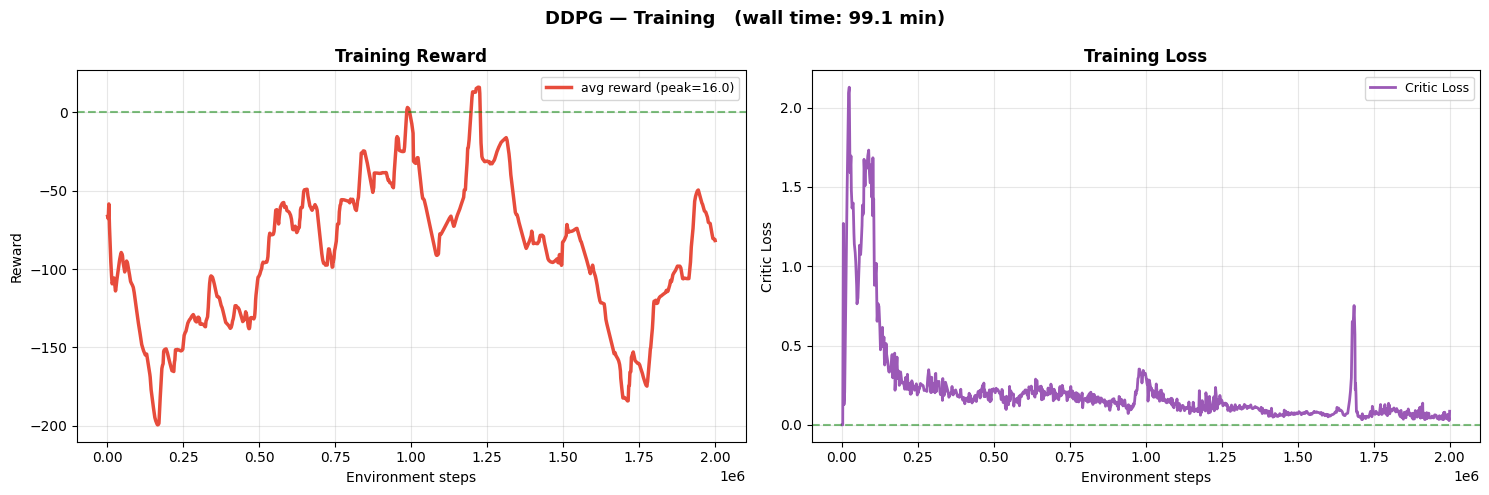

Saved: ddpg_loss_reward.png


In [22]:
# === PLOT: reward + loss (1x2) ===
def plot_loss_reward(logger, algo="DDPG", save_prefix=None):
    save_prefix = save_prefix or algo.lower()
    steps_ts  = [r["steps"]      for r in logger.rows]
    reward_ts = [r["avg_reward"] for r in logger.rows]
    loss_ts   = [r["loss"]       for r in logger.rows]
    wt = logger.rows[-1]["wall_time"] if logger.rows else 0

    fig, (axr, axl) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"{algo} — Training   (wall time: {wt/60:.1f} min)",
                 fontsize=13, fontweight="bold")

    axr.plot(steps_ts, reward_ts, color="#E74C3C", lw=2.5,
             label=f"avg reward (peak={max(reward_ts):.1f})")
    axr.axhline(0, color="green", ls="--", alpha=0.5)
    axr.set_xlabel("Environment steps"); axr.set_ylabel("Reward")
    axr.set_title("Training Reward", fontweight="bold")
    axr.legend(fontsize=9); axr.grid(alpha=0.3)

    axl.plot(steps_ts, loss_ts, color="#9B59B6", lw=2, label="Critic Loss")
    axl.axhline(0, color="green", ls="--", alpha=0.5)
    axl.set_xlabel("Environment steps"); axl.set_ylabel("Critic Loss")
    axl.set_title("Training Loss", fontweight="bold")
    axl.legend(fontsize=9); axl.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{save_prefix}_loss_reward.png", dpi=150, bbox_inches="tight")
    plt.show(); print(f"Saved: {save_prefix}_loss_reward.png")

plot_loss_reward(logger, algo="DDPG")

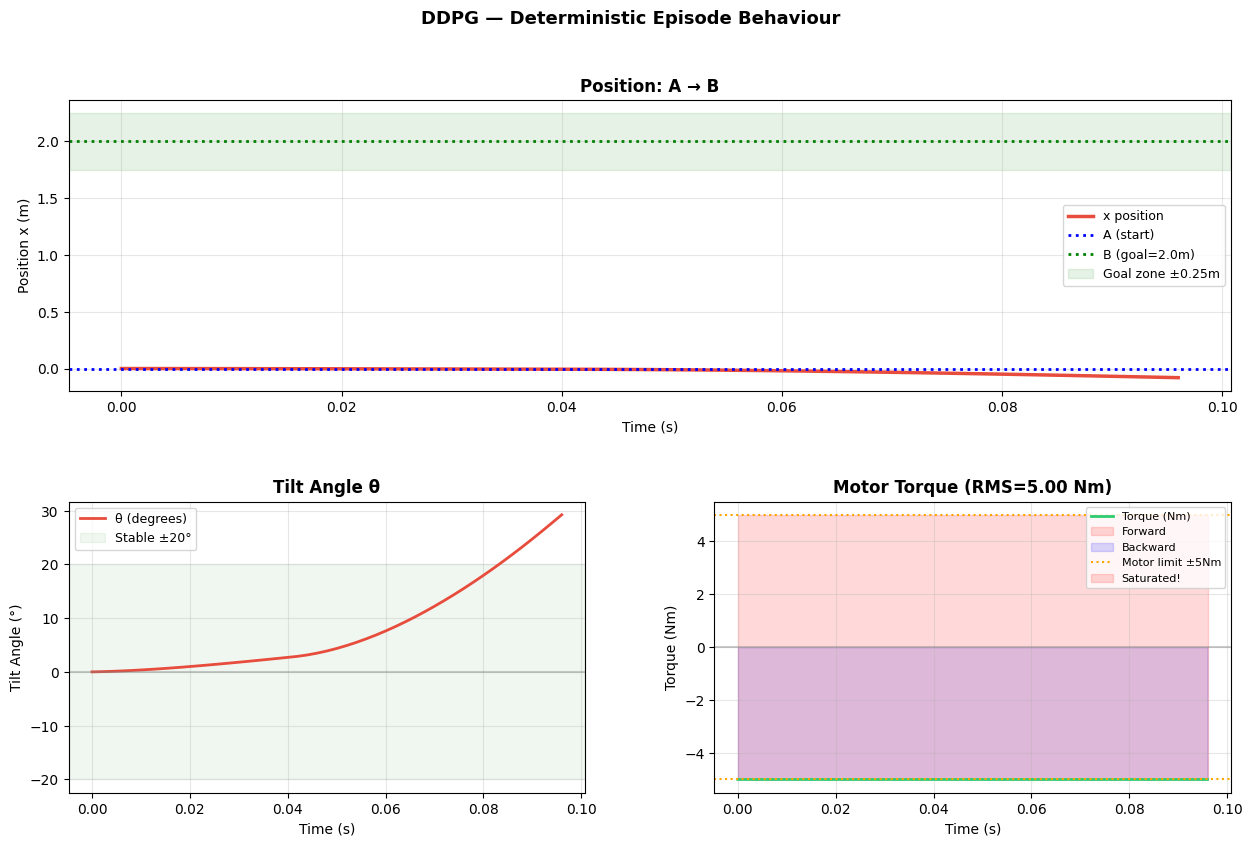


  Duration: 0.1s | Max x: -0.000m | Avg tilt: 8.1° | Max tilt: 29.2° | Torque RMS: 5.000 Nm | Saturated: 49/49 (100%)


In [23]:
# === PLOT: episode traces (position, tilt, torque) ===
def plot_episode_traces(net, algo="DDPG", x_goal=2.0, save_prefix=None):
    save_prefix = save_prefix or algo.lower()
    model=mujoco.MjModel.from_xml_path(XML_PATH); data=mujoco.MjData(model)
    dt=model.opt.timestep; mujoco.mj_resetData(model,data)
    data.qpos[0]=0.0; data.qpos[2]=get_z_for_tilt(0.0)
    data.qpos[3:7]=[1,0,0,0]; data.qvel[:]=0.0; mujoco.mj_forward(model,data)
    obs=get_obs(data); ts,xs,ths,torqs=[],[],[],[]; prev_x=0.0
    for step in range(3000):
        with torch.no_grad():
            torque,_,_=net.get_action(obs,x_goal,deterministic=True)
        u=float(np.clip(torque,-5,5)); data.ctrl[0]=-u; data.ctrl[1]=0.0
        mujoco.mj_step(model,data); obs=get_obs(data); x,xd,th,thd=obs
        ts.append(step*dt); xs.append(x); ths.append(np.degrees(th)); torqs.append(torque)
        prev_x=x
        if abs(x)>2.8 or abs(th)>0.5 or (abs(x-x_goal)<0.25 and abs(th)<0.35): break
    ts=np.array(ts); xs=np.array(xs); ths=np.array(ths); torqs=np.array(torqs)
    arrived=abs(xs[-1]-x_goal)<0.25 and abs(ths[-1])<20
    rms=np.sqrt(np.mean(torqs**2)); sat=np.abs(torqs)>4.8

    fig=plt.figure(figsize=(15,9))
    gs=gridspec.GridSpec(2,2,hspace=0.38,wspace=0.25,figure=fig)
    fig.suptitle(f"{algo} — Deterministic Episode Behaviour", fontsize=13, fontweight="bold")

    ax=fig.add_subplot(gs[0,:])
    ax.plot(ts,xs,"#E74C3C",lw=2.5,label="x position")
    ax.axhline(0,color="blue",ls=":",lw=2,label="A (start)")
    ax.axhline(x_goal,color="green",ls=":",lw=2,label=f"B (goal={x_goal}m)")
    ax.axhspan(x_goal-0.25,x_goal+0.25,alpha=0.1,color="green",label="Goal zone ±0.25m")
    if arrived:
        idx=np.where(np.abs(xs-x_goal)<0.25)[0][0]
        ax.axvline(ts[idx],color="green",ls="--",alpha=0.6)
        ax.annotate(f"ARRIVED\nt={ts[idx]:.1f}s",xy=(ts[idx],xs[idx]),
                    xytext=(ts[idx]+0.2,x_goal-0.3),color="green",fontsize=9,
                    arrowprops=dict(arrowstyle="->",color="green"))
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Position x (m)")
    ax.set_title("Position: A → B",fontweight="bold"); ax.legend(fontsize=9); ax.grid(alpha=0.3)

    ax=fig.add_subplot(gs[1,0])
    ax.plot(ts,ths,"#E74C3C",lw=2,label="θ (degrees)")
    ax.axhspan(-20,20,alpha=0.06,color="green",label="Stable ±20°")
    ax.axhline(0,color="gray",alpha=0.4)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Tilt Angle (°)")
    ax.set_title("Tilt Angle θ",fontweight="bold"); ax.legend(fontsize=9); ax.grid(alpha=0.3)

    ax=fig.add_subplot(gs[1,1])
    ax.plot(ts,torqs,"#2ECC71",lw=2,label="Torque (Nm)")
    ax.fill_between(ts,torqs,0,where=(torqs>0),alpha=0.15,color="red",label="Forward")
    ax.fill_between(ts,torqs,0,where=(torqs<0),alpha=0.15,color="blue",label="Backward")
    ax.axhline(5,color="orange",ls=":",lw=1.5,label="Motor limit ±5Nm")
    ax.axhline(-5,color="orange",ls=":",lw=1.5); ax.axhline(0,color="gray",alpha=0.4)
    if sat.any(): ax.fill_between(ts,-5,5,where=sat,alpha=0.15,color="red",label="Saturated!")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Torque (Nm)")
    ax.set_title(f"Motor Torque (RMS={rms:.2f} Nm)",fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.savefig(f"{save_prefix}_episode_traces.png",dpi=150,bbox_inches="tight")
    plt.show()
    print(f"\n  Duration: {ts[-1]:.1f}s | Max x: {max(xs):.3f}m | Avg tilt: {np.mean(np.abs(ths)):.1f}°"
          f" | Max tilt: {max(np.abs(ths)):.1f}° | Torque RMS: {rms:.3f} Nm"
          f" | Saturated: {sat.sum()}/{len(ts)} ({sat.mean()*100:.0f}%)")

plot_episode_traces(net, algo="DDPG")